In [124]:
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import WeightedRandomSampler
# from torch_geometric.loader import DataLoader
# from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# # -------------------------
# # Model (Graph-level)
# # -------------------------
# class PatientGraphGNN(nn.Module):
#     def __init__(self, in_dim, hidden_dim=16, num_layers=1, dropout=0.5):
#         super().__init__()
#         self.convs = nn.ModuleList()
#         self.convs.append(SAGEConv(in_dim, hidden_dim))
#         for _ in range(num_layers - 1):
#             self.convs.append(SAGEConv(hidden_dim, hidden_dim))

#         self.mlp = nn.Sequential(
#             nn.Linear(hidden_dim * 2, hidden_dim),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(hidden_dim, 1),
#         )
#         self.dropout = dropout

#     def forward(self, data):
#         x, edge_index = data.x, data.edge_index
#         for conv in self.convs:
#             x = conv(x, edge_index)
#             x = F.relu(x)
#             x = F.dropout(x, p=self.dropout, training=self.training)

#         g = torch.cat([global_mean_pool(x, data.batch), global_max_pool(x, data.batch)], dim=-1)
#         return self.mlp(g).squeeze(-1)


# # -------------------------
# # Utilities: metrics + threshold
# # -------------------------
# @torch.no_grad()
# def collect_logits_and_labels(model, loader):
#     model.eval()
#     logits_all, y_all = [], []
#     for batch in loader:
#         batch = batch.to(device)
#         logits_all.append(model(batch).detach().cpu())
#         y_all.append(batch.y.view(-1).detach().cpu().long())
#     return torch.cat(logits_all), torch.cat(y_all)

# def metrics_at_threshold(probs, y_true, thr):
#     preds = (probs >= thr).long()
#     tp = int(((preds == 1) & (y_true == 1)).sum())
#     tn = int(((preds == 0) & (y_true == 0)).sum())
#     fp = int(((preds == 1) & (y_true == 0)).sum())
#     fn = int(((preds == 0) & (y_true == 1)).sum())

#     acc = (tp + tn) / max(tp + tn + fp + fn, 1)
#     tpr = tp / max(tp + fn, 1)
#     tnr = tn / max(tn + fp, 1)
#     bal_acc = 0.5 * (tpr + tnr)

#     prec = tp / max(tp + fp, 1)
#     f1 = (2 * prec * tpr) / max(prec + tpr, 1e-12)

#     # AUROC via ranks (small-N friendly)
#     y_np = y_true.numpy()
#     if len(set(y_np.tolist())) < 2:
#         auroc = float("nan")
#     else:
#         p = probs.numpy()
#         order = np.argsort(p)
#         ranks = np.empty_like(order, dtype=float)
#         ranks[order] = np.arange(len(p)) + 1
#         pos_ranks_sum = ranks[y_np == 1].sum()
#         n_pos = (y_np == 1).sum()
#         n_neg = (y_np == 0).sum()
#         auroc = (pos_ranks_sum - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

#     return {"acc": acc, "bal_acc": bal_acc, "f1": f1, "auroc": auroc,
#             "tp": tp, "tn": tn, "fp": fp, "fn": fn}

# def find_best_threshold(probs, y_true, objective="bal_acc"):
#     thrs = np.linspace(0.05, 0.95, 181)
#     best_thr, best_val, best_m = 0.5, -1.0, None
#     for t in thrs:
#         m = metrics_at_threshold(probs, y_true, float(t))
#         if m[objective] > best_val:
#             best_val, best_thr, best_m = m[objective], float(t), m
#     return best_thr, best_m


# # -------------------------
# # Stratified K-Fold split (no sklearn)
# # -------------------------
# def stratified_kfold_indices(y, k=5, seed=42):
#     """
#     y: list[int] 0/1
#     returns: list of (train_idx, test_idx)
#     """
#     rng = np.random.default_rng(seed)
#     y = np.array(y, dtype=int)
#     idx0 = np.where(y == 0)[0]
#     idx1 = np.where(y == 1)[0]
#     rng.shuffle(idx0)
#     rng.shuffle(idx1)

#     folds0 = np.array_split(idx0, k)
#     folds1 = np.array_split(idx1, k)

#     splits = []
#     for i in range(k):
#         test_idx = np.concatenate([folds0[i], folds1[i]])
#         train_idx = np.concatenate([np.concatenate([folds0[j] for j in range(k) if j != i]),
#                                     np.concatenate([folds1[j] for j in range(k) if j != i])])
#         rng.shuffle(train_idx)
#         rng.shuffle(test_idx)
#         splits.append((train_idx.tolist(), test_idx.tolist()))
#     return splits


# # -------------------------
# # Balanced sampler
# # -------------------------
# def make_balanced_sampler(graphs):
#     ys = [int(g.y.view(-1)[0].item()) for g in graphs]
#     n0 = sum(y == 0 for y in ys)
#     n1 = sum(y == 1 for y in ys)
#     w0 = 1.0 / max(n0, 1)
#     w1 = 1.0 / max(n1, 1)
#     weights = [w1 if y == 1 else w0 for y in ys]
#     return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


# # -------------------------
# # K-Fold training
# # -------------------------
# def run_kfold_cv(
#     graphs,
#     k=10,
#     seed=42,
#     epochs=500,
#     patience=50,
#     batch_size=16,
#     lr=1e-3,
#     weight_decay=5e-4,
#     hidden_dim=16,
#     num_layers=1,
#     dropout=0.5,
#     threshold_objective="bal_acc",  # or "f1"
#     use_balanced_sampler=True,
# ):
#     ys = [int(g.y.view(-1)[0].item()) for g in graphs]
#     splits = stratified_kfold_indices(ys, k=k, seed=seed)

#     in_dim = graphs[0].x.size(-1)

#     fold_results = []
#     for fold, (train_idx, test_idx) in enumerate(splits, start=1):
#         # Build train/test sets
#         train_set = [graphs[i] for i in train_idx]
#         test_set  = [graphs[i] for i in test_idx]

#         # Further split train into train/val (stratified) for early stopping + threshold tuning
#         y_train = [int(g.y.view(-1)[0].item()) for g in train_set]
#         inner_splits = stratified_kfold_indices(y_train, k=5, seed=seed + fold)
#         inner_train_idx, val_idx = inner_splits[0]  # take first split as val
#         inner_train_set = [train_set[i] for i in inner_train_idx]
#         val_set = [train_set[i] for i in val_idx]

#         # pos_weight from inner_train only
#         y_it = torch.tensor([int(g.y.view(-1)[0].item()) for g in inner_train_set], dtype=torch.long)
#         n_pos = int((y_it == 1).sum().item())
#         n_neg = int((y_it == 0).sum().item())
#         pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=device, dtype=torch.float32)

#         # Loaders
#         if use_balanced_sampler:
#             sampler = make_balanced_sampler(inner_train_set)
#             train_loader = DataLoader(inner_train_set, batch_size=batch_size, sampler=sampler)
#         else:
#             train_loader = DataLoader(inner_train_set, batch_size=batch_size, shuffle=True)

#         val_loader  = DataLoader(val_set, batch_size=batch_size, shuffle=False)
#         test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

#         # Model
#         model = PatientGraphGNN(in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout).to(device)
#         opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

#         best_state = None
#         best_val_obj = -1.0
#         best_thr = 0.5
#         no_improve = 0

#         for ep in range(1, epochs + 1):
#             model.train()
#             for batch in train_loader:
#                 batch = batch.to(device)
#                 opt.zero_grad()
#                 logits = model(batch)
#                 yb = batch.y.view(-1).float()
#                 loss = F.binary_cross_entropy_with_logits(logits, yb, pos_weight=pos_weight)
#                 loss.backward()
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
#                 opt.step()

#             # ---- Validation: tune threshold on val each epoch ----
#             val_logits, val_y = collect_logits_and_labels(model, val_loader)
#             val_probs = torch.sigmoid(val_logits)
#             thr, thr_metrics = find_best_threshold(val_probs, val_y, objective=threshold_objective)

#             val_obj = thr_metrics[threshold_objective]
#             if val_obj > best_val_obj:
#                 best_val_obj = val_obj
#                 best_thr = thr
#                 best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
#                 no_improve = 0
#             else:
#                 no_improve += 1
#                 if no_improve >= patience:
#                     break

#         # Restore best
#         model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

#         # Final eval on test fold using best_thr from val
#         test_logits, test_y = collect_logits_and_labels(model, test_loader)
#         test_probs = torch.sigmoid(test_logits)

#         test_metrics = metrics_at_threshold(test_probs, test_y, best_thr)
#         test_metrics["best_thr"] = best_thr
#         test_metrics["test_probs"] = test_probs.numpy()
#         test_metrics["test_y"] = test_y.numpy()

#         fold_results.append(test_metrics)

#         # Print fold summary
#         n_test_pos = int((test_y == 1).sum().item())
#         n_test_neg = int((test_y == 0).sum().item())
#         print(
#             f"Fold {fold}/{k} | test (pos={n_test_pos}, neg={n_test_neg}) "
#             f"| thr={best_thr:.3f} | acc={test_metrics['acc']:.3f} "
#             f"| bal_acc={test_metrics['bal_acc']:.3f} | f1={test_metrics['f1']:.3f} "
#             f"| auroc={test_metrics['auroc']:.3f} | tp={test_metrics['tp']} tn={test_metrics['tn']} "
#             f"fp={test_metrics['fp']} fn={test_metrics['fn']}"
#         )

#     # Aggregate
#     def mean_std(key):
#         vals = [r[key] for r in fold_results if not (isinstance(r[key], float) and np.isnan(r[key]))]
#         return float(np.mean(vals)), float(np.std(vals))

#     print("\n===== 5-FOLD SUMMARY (mean ± std) =====")
#     for key in ["acc", "bal_acc", "f1", "auroc"]:
#         m, s = mean_std(key)
#         print(f"{key:8s}: {m:.3f} ± {s:.3f}")

#     # Also show thresholds
#     thrs = [r["best_thr"] for r in fold_results]
#     print(f"best_thr : {float(np.mean(thrs)):.3f} ± {float(np.std(thrs)):.3f}")

#     return fold_results, model



In [125]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Model (Graph-level)
# -------------------------
class PatientGraphGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=16, num_layers=1, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))

        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        g = torch.cat(
            [global_mean_pool(x, data.batch), global_max_pool(x, data.batch)],
            dim=-1
        )
        return self.mlp(g).squeeze(-1)


# -------------------------
# Metrics
# -------------------------
def auroc_from_probs(probs: torch.Tensor, y_true: torch.Tensor) -> float:
    """AUROC via ranks; probs,y_true on CPU, 1D, y_true in {0,1}."""
    y = y_true.numpy().astype(int)
    if len(set(y.tolist())) < 2:
        return float("nan")
    p = probs.numpy()
    order = np.argsort(p)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(p)) + 1
    pos_ranks_sum = ranks[y == 1].sum()
    n_pos = (y == 1).sum()
    n_neg = (y == 0).sum()
    return float((pos_ranks_sum - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def metrics_at_threshold(probs, y_true, thr):
    preds = (probs >= thr).long()
    tp = int(((preds == 1) & (y_true == 1)).sum())
    tn = int(((preds == 0) & (y_true == 0)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())

    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    tpr = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    bal_acc = 0.5 * (tpr + tnr)

    prec = tp / max(tp + fp, 1)
    f1 = (2 * prec * tpr) / max(prec + tpr, 1e-12)

    auroc = auroc_from_probs(probs, y_true)
    return {"acc": acc, "bal_acc": bal_acc, "f1": f1, "auroc": auroc,
            "tp": tp, "tn": tn, "fp": fp, "fn": fn}


def find_best_threshold(probs, y_true, objective="bal_acc"):
    thrs = np.linspace(0.05, 0.95, 181)
    best_thr, best_val, best_m = 0.5, -1.0, None
    for t in thrs:
        m = metrics_at_threshold(probs, y_true, float(t))
        if m[objective] > best_val:
            best_val, best_thr, best_m = m[objective], float(t), m
    return best_thr, best_m


@torch.no_grad()
def collect_logits_and_labels(model, loader):
    model.eval()
    logits_all, y_all = [], []
    for batch in loader:
        batch = batch.to(device)
        logits_all.append(model(batch).detach().cpu())
        y_all.append(batch.y.view(-1).detach().cpu().long())
    return torch.cat(logits_all), torch.cat(y_all)


# -------------------------
# Stratified splits (no sklearn)
# -------------------------
def stratified_kfold_indices(y, k=5, seed=42):
    rng = np.random.default_rng(seed)
    y = np.array(y, dtype=int)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    rng.shuffle(idx0)
    rng.shuffle(idx1)

    folds0 = np.array_split(idx0, k)
    folds1 = np.array_split(idx1, k)

    splits = []
    for i in range(k):
        test_idx = np.concatenate([folds0[i], folds1[i]])
        train_idx = np.concatenate([
            np.concatenate([folds0[j] for j in range(k) if j != i]),
            np.concatenate([folds1[j] for j in range(k) if j != i]),
        ])
        rng.shuffle(train_idx)
        rng.shuffle(test_idx)
        splits.append((train_idx.tolist(), test_idx.tolist()))
    return splits


def stratified_train_val_split(y, val_frac=0.2, seed=123):
    rng = np.random.default_rng(seed)
    y = np.array(y, dtype=int)
    idx0 = np.where(y == 0)[0].tolist()
    idx1 = np.where(y == 1)[0].tolist()
    rng.shuffle(idx0); rng.shuffle(idx1)

    n0_val = int(round(len(idx0) * val_frac))
    n1_val = int(round(len(idx1) * val_frac))

    val_idx = idx0[:n0_val] + idx1[:n1_val]
    train_idx = idx0[n0_val:] + idx1[n1_val:]
    rng.shuffle(train_idx); rng.shuffle(val_idx)
    return train_idx, val_idx


# -------------------------
# Training one fold with:
# - early stop on val AUROC
# - threshold tuned once after early stopping
# - pos_weight only (no sampler)
# -------------------------
def train_one_split(
    train_set,
    val_set,
    in_dim,
    hidden_dim=16,
    num_layers=1,
    dropout=0.5,
    lr=1e-3,
    weight_decay=5e-4,
    batch_size=16,
    epochs=500,
    patience=50,
    threshold_objective="bal_acc",
):
    # pos_weight computed from TRAIN ONLY
    y_train = torch.tensor([int(g.y.view(-1)[0].item()) for g in train_set], dtype=torch.long)
    n_pos = int((y_train == 1).sum().item())
    n_neg = int((y_train == 0).sum().item())
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=device, dtype=torch.float32)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    model = PatientGraphGNN(in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_auroc = -1.0
    no_improve = 0

    for ep in range(1, epochs + 1):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            logits = model(batch)
            yb = batch.y.view(-1).float()
            loss = F.binary_cross_entropy_with_logits(logits, yb, pos_weight=pos_weight)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()

        # ---- early stopping on val AUROC ----
        val_logits, val_y = collect_logits_and_labels(model, val_loader)
        val_probs = torch.sigmoid(val_logits)
        val_auroc = auroc_from_probs(val_probs, val_y)

        # if AUROC is nan (e.g., val has one class), fall back to -inf so it won't be selected
        if np.isnan(val_auroc):
            val_auroc = -1e9

        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    # restore best
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    # ---- tune threshold ONCE on validation after early stopping ----
    val_logits, val_y = collect_logits_and_labels(model, val_loader)
    val_probs = torch.sigmoid(val_logits)
    best_thr, _ = find_best_threshold(val_probs, val_y, objective=threshold_objective)

    return model, float(best_thr), float(best_val_auroc)


# -------------------------
# Repeated 5-fold CV + uncertainty + save final model
# -------------------------
def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    vals = np.array(values, dtype=float)
    if len(vals) == 0:
        return (float("nan"), float("nan"))
    boots = []
    for _ in range(n_boot):
        sample = rng.choice(vals, size=len(vals), replace=True)
        boots.append(sample.mean())
    lo = float(np.quantile(boots, alpha / 2))
    hi = float(np.quantile(boots, 1 - alpha / 2))
    return lo, hi


def run_repeated_5fold_cv_and_train_final(
    graphs,
    repeats=10,
    k=5,
    seed=42,
    epochs=500,
    patience=50,
    batch_size=16,
    lr=1e-3,
    weight_decay=5e-4,
    hidden_dim=16,
    num_layers=1,
    dropout=0.5,
    threshold_objective="bal_acc",
    final_val_frac=0.2,
    save_path="patient_gnn_final.pt",
):
    ys = [int(g.y.view(-1)[0].item()) for g in graphs]
    in_dim = graphs[0].x.size(-1)

    all_fold_results = []
    all_models = []  # optional: keep if you want; can be large

    for r in range(repeats):
        splits = stratified_kfold_indices(ys, k=k, seed=seed + 1000 * r)
        for fold, (train_idx, test_idx) in enumerate(splits, start=1):
            train_full = [graphs[i] for i in train_idx]
            test_set   = [graphs[i] for i in test_idx]

            # make a stratified train/val split from train_full for early stopping + threshold tuning
            y_train_full = [int(g.y.view(-1)[0].item()) for g in train_full]
            tr_idx, val_idx = stratified_train_val_split(y_train_full, val_frac=final_val_frac, seed=seed + 1000 * r + fold)

            train_set = [train_full[i] for i in tr_idx]
            val_set   = [train_full[i] for i in val_idx]

            model, best_thr, best_val_auroc = train_one_split(
                train_set=train_set,
                val_set=val_set,
                in_dim=in_dim,
                hidden_dim=hidden_dim,
                num_layers=num_layers,
                dropout=dropout,
                lr=lr,
                weight_decay=weight_decay,
                batch_size=batch_size,
                epochs=epochs,
                patience=patience,
                threshold_objective=threshold_objective,
            )

            # test evaluation (using threshold tuned ONCE on val)
            test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
            test_logits, test_y = collect_logits_and_labels(model, test_loader)
            test_probs = torch.sigmoid(test_logits)

            m = metrics_at_threshold(test_probs, test_y, best_thr)
            m.update({
                "repeat": r,
                "fold": fold,
                "best_thr": best_thr,
                "best_val_auroc": best_val_auroc,
                "n_test": int(len(test_y)),
                "n_test_pos": int((test_y == 1).sum().item()),
                "n_test_neg": int((test_y == 0).sum().item()),
            })
            all_fold_results.append(m)
            all_models.append(model)

            print(
                f"[rep {r+1}/{repeats} | fold {fold}/{k}] "
                f"val_auroc={best_val_auroc:.3f} thr={best_thr:.3f} "
                f"test bal_acc={m['bal_acc']:.3f} f1={m['f1']:.3f} auroc={m['auroc']:.3f} "
                f"(pos={m['n_test_pos']}, neg={m['n_test_neg']})"
            )

    # ---- aggregate + CIs over all repeat×fold test results ----
    summary = {}
    for key in ["acc", "bal_acc", "f1", "auroc"]:
        vals = [x[key] for x in all_fold_results if not (isinstance(x[key], float) and np.isnan(x[key]))]
        mean = float(np.mean(vals)) if len(vals) else float("nan")
        std  = float(np.std(vals))  if len(vals) else float("nan")
        ci_lo, ci_hi = bootstrap_ci(vals, n_boot=2000, alpha=0.05, seed=seed)
        summary[key] = {"mean": mean, "std": std, "ci95": (ci_lo, ci_hi), "n": len(vals)}

    thr_vals = [x["best_thr"] for x in all_fold_results]
    summary["best_thr"] = {
        "mean": float(np.mean(thr_vals)),
        "std": float(np.std(thr_vals)),
        "ci95": bootstrap_ci(thr_vals, n_boot=2000, alpha=0.05, seed=seed),
        "n": len(thr_vals),
    }

    print("\n===== REPEATED 5-FOLD SUMMARY (test; pooled over repeats×folds) =====")
    for k_ in ["acc", "bal_acc", "f1", "auroc"]:
        s = summary[k_]
        print(f"{k_:8s}: {s['mean']:.3f} ± {s['std']:.3f} | 95% CI [{s['ci95'][0]:.3f}, {s['ci95'][1]:.3f}] | n={s['n']}")
    s = summary["best_thr"]
    print(f"best_thr: {s['mean']:.3f} ± {s['std']:.3f} | 95% CI [{s['ci95'][0]:.3f}, {s['ci95'][1]:.3f}] | n={s['n']}")

    # ---- train FINAL model on ALL data with a small stratified val split ----
    # (we keep a val split so early stopping is meaningful; threshold tuned on that val split)
    tr_idx, val_idx = stratified_train_val_split(ys, val_frac=final_val_frac, seed=seed + 99999)
    train_set = [graphs[i] for i in tr_idx]
    val_set   = [graphs[i] for i in val_idx]

    final_model, final_thr, final_val_auroc = train_one_split(
        train_set=train_set,
        val_set=val_set,
        in_dim=in_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        batch_size=batch_size,
        epochs=epochs,
        patience=patience,
        threshold_objective=threshold_objective,
    )

    # Save: weights + threshold + config + CV summary
    payload = {
        "state_dict": {k: v.detach().cpu() for k, v in final_model.state_dict().items()},
        "threshold": float(final_thr),
        "val_auroc": float(final_val_auroc),
        "config": {
            "in_dim": int(in_dim),
            "hidden_dim": hidden_dim,
            "num_layers": num_layers,
            "dropout": dropout,
            "lr": lr,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "epochs": epochs,
            "patience": patience,
            "threshold_objective": threshold_objective,
            "final_val_frac": final_val_frac,
            "repeats": repeats,
            "k": k,
            "seed": seed,
            "pos_weight_used": True,
            "balanced_sampler_used": False,
        },
        "cv_summary": summary,
        "cv_fold_results": all_fold_results,  # optional but useful
    }
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    torch.save(payload, save_path)
    print(f"\nSaved final model to: {save_path}")
    print(f"Final threshold (tuned on final val split): {final_thr:.3f} | final val AUROC: {final_val_auroc:.3f}")

    return all_fold_results, summary, final_model, final_thr


# -------------------------
# Loading the saved model later
# -------------------------
def load_saved_patient_model(path):
    ckpt = torch.load(path, map_location="cpu")
    cfg = ckpt["config"]
    model = PatientGraphGNN(
        in_dim=cfg["in_dim"],
        hidden_dim=cfg["hidden_dim"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
    )
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    threshold = float(ckpt["threshold"])
    return model, threshold, ckpt


In [126]:
import os
import glob
import torch
from torch_geometric.data import Data

def load_graphs_and_tables(graph_dir: str):
    """
    Loads .pt files saved as: torch.save((graph, table), path)
    Returns:
      graphs: list[Data]
      tables: list[object]  (often pandas.DataFrame)
      paths:  list[str]
    """
    paths = sorted(glob.glob(os.path.join(graph_dir, "*.pt")))
    if not paths:
        raise FileNotFoundError(f"No .pt files found in: {graph_dir}")

    graphs, tables, used_paths = [], [], []
    for p in paths:
        graph, table = torch.load(p, map_location="cpu", weights_only=False)
        if not isinstance(graph, Data):
            raise TypeError(f"{p}: first element is {type(graph)}, expected torch_geometric.data.Data")
        graphs.append(graph)
        tables.append(table)
        used_paths.append(p)

    print(f"Loaded {len(graphs)} (graph, table) pairs from {graph_dir}")
    return graphs, tables, used_paths


In [127]:
downsample_size = 600
chain = "AB"
distance_threshold=0.08
use_mst=True
enrich=True
save_path = f"models/{chain}_{distance_threshold}_{use_mst}_{enrich}"

In [128]:
graphs, tables, used_paths = load_graphs_and_tables(f"/dsi/efroni-lab/sbm/chen2/graph_data/ovarian/{chain}/{downsample_size}/{distance_threshold}_{use_mst}_{enrich}/")

fold_results, summary, final_model, final_thr = run_repeated_5fold_cv_and_train_final(
    graphs,
    repeats=5,
    k=3,
    seed=42,
    epochs=500,
    patience=50,
    batch_size=16,
    lr=1e-3,
    weight_decay=5e-4,
    hidden_dim=16,
    num_layers=1,
    dropout=0.5,
    threshold_objective="bal_acc",
    final_val_frac=0.2,
    save_path=f"{save_path}/patient_gnn_final.pt",
)


Loaded 84 (graph, table) pairs from /dsi/efroni-lab/sbm/chen2/graph_data/ovarian/AB/600/0.08_True_True/


/home/dsi/chenbis/anaconda3/envs/chephy2/lib/python3.10/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


[rep 1/5 | fold 1/3] val_auroc=1.000 thr=0.050 test bal_acc=0.500 f1=0.585 auroc=0.446 (pos=12, neg=17)
[rep 1/5 | fold 2/3] val_auroc=0.914 thr=0.490 test bal_acc=0.428 f1=0.125 auroc=0.390 (pos=11, neg=17)
[rep 1/5 | fold 3/3] val_auroc=0.800 thr=0.415 test bal_acc=0.736 f1=0.714 auroc=0.744 (pos=11, neg=16)
[rep 2/5 | fold 1/3] val_auroc=0.786 thr=0.050 test bal_acc=0.500 f1=0.585 auroc=0.373 (pos=12, neg=17)
[rep 2/5 | fold 2/3] val_auroc=0.886 thr=0.520 test bal_acc=0.548 f1=0.353 auroc=0.727 (pos=11, neg=17)
[rep 2/5 | fold 3/3] val_auroc=0.743 thr=0.525 test bal_acc=0.616 f1=0.545 auroc=0.727 (pos=11, neg=16)
[rep 3/5 | fold 1/3] val_auroc=0.786 thr=0.050 test bal_acc=0.500 f1=0.585 auroc=0.657 (pos=12, neg=17)
[rep 3/5 | fold 2/3] val_auroc=0.686 thr=0.050 test bal_acc=0.500 f1=0.564 auroc=0.406 (pos=11, neg=17)
[rep 3/5 | fold 3/3] val_auroc=0.943 thr=0.050 test bal_acc=0.500 f1=0.579 auroc=0.523 (pos=11, neg=16)
[rep 4/5 | fold 1/3] val_auroc=0.893 thr=0.050 test bal_acc=0.50

In [129]:
import json
import pickle

# Save results to JSON (metrics only, without numpy arrays)
results_json = []
for r in fold_results:
    r_json = {k: v for k, v in r.items() if k not in ["test_probs", "test_y"]}
    results_json.append(r_json)

with open(f"{save_path}/cv_results_metrics.json", "w") as f:
    json.dump(results_json, f, indent=2)

# Save full results (including arrays) as pickle
with open(f"{save_path}/cv_results_full.pkl", "wb") as f:
    pickle.dump(fold_results, f)

print("Results saved to cv_results_metrics.json and cv_results_full.pkl")

# Create loader functions
def load_results_json(filepath=f"{save_path}/cv_results_metrics.json"):
    """Load metrics from JSON file"""
    with open(filepath, "r") as f:
        return json.load(f)

def load_results_full(filepath=f"{save_path}/cv_results_full.pkl"):
    """Load full results (with test_probs and test_y) from pickle file"""
    with open(filepath, "rb") as f:
        return pickle.load(f)

# Test the loaders
loaded_results = load_results_full()
print(f"Loaded {len(loaded_results)} fold results from pickle")

Results saved to cv_results_metrics.json and cv_results_full.pkl
Loaded 15 fold results from pickle


/tmp/ipykernel_1584665/3140052546.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=metrics, showmeans=True)


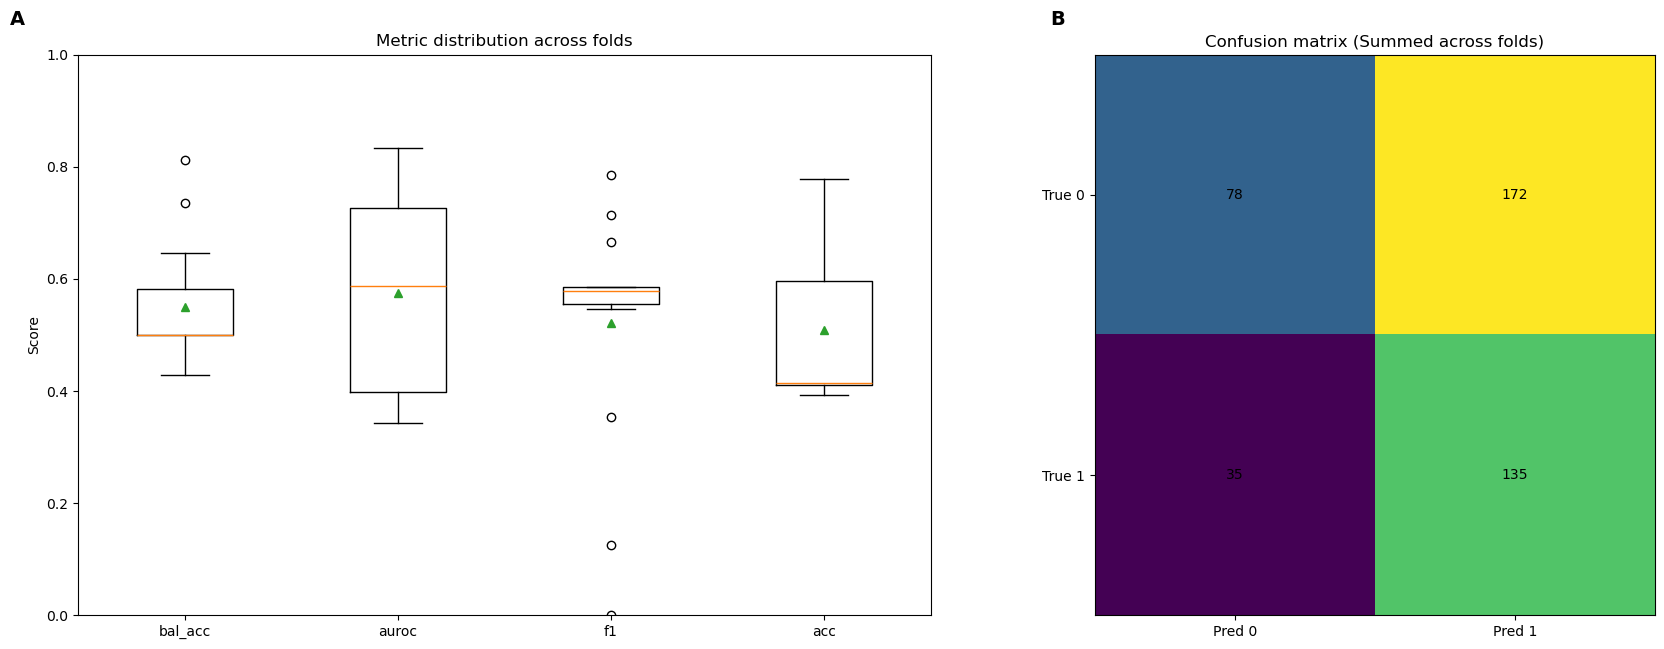

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve

def add_panel_labels(axes, labels=("A", "B")):
    for ax, lab in zip(axes.flat, labels):
        ax.text(
            -0.08, 1.08, lab,
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
            va="top",
            ha="left"
        )

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)


ax = axes[0, 0]
metrics=("bal_acc", "auroc", "f1", "acc")
title="Metric distribution across folds"
data = [np.array([r[m] for r in fold_results], dtype=float) for m in metrics]

ax.boxplot(data, labels=metrics, showmeans=True)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title(title)

ax = axes[0, 1]
title_prefix="Confusion matrix"

# overall summed
tn = sum(r["tn"] for r in fold_results)
fp = sum(r["fp"] for r in fold_results)
fn = sum(r["fn"] for r in fold_results)
tp = sum(r["tp"] for r in fold_results)
cm_all = np.array([[tn, fp],
                    [fn, tp]], dtype=int)

ax.imshow(cm_all, interpolation="nearest")
ax.set_title(f"{title_prefix} (Summed across folds)")
ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], ["True 0", "True 1"])
for (y, x), val in np.ndenumerate(cm_all):
    ax.text(x, y, str(val), ha="center", va="center")
# ax.colorbar()




fig.delaxes(axes[1, 1])
fig.delaxes(axes[1, 0])

add_panel_labels(axes[:1], labels=("A", "B"))
plt.show()


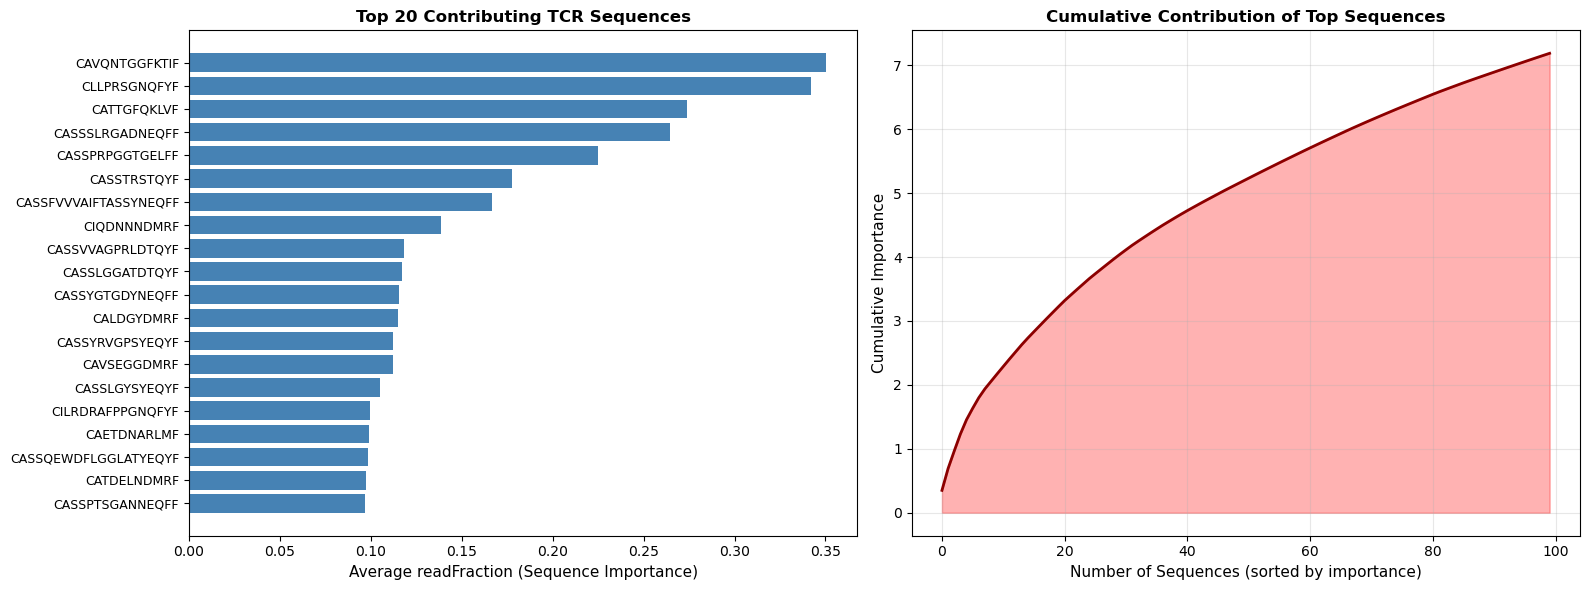

Top 30 Contributing Sequences (by Average readFraction):
--------------------------------------------------------------------------------
 1. CAVQNTGGFKTIF             | avg_importance=0.350067 | found_in_1_patients
 2. CLLPRSGNQFYF              | avg_importance=0.341844 | found_in_1_patients
 3. CATTGFQKLVF               | avg_importance=0.273776 | found_in_1_patients
 4. CASSSLRGADNEQFF           | avg_importance=0.264724 | found_in_1_patients
 5. CASSPRPGGTGELFF           | avg_importance=0.225063 | found_in_1_patients
 6. CASSTRSTQYF               | avg_importance=0.177659 | found_in_2_patients
 7. CASSFVVVAIFTASSYNEQFF     | avg_importance=0.166734 | found_in_1_patients
 8. CIQDNNNDMRF               | avg_importance=0.138597 | found_in_1_patients
 9. CASSVVAGPRLDTQYF          | avg_importance=0.118065 | found_in_1_patients
10. CASSLGGATDTQYF            | avg_importance=0.117177 | found_in_2_patients
11. CASSYGTGDYNEQFF           | avg_importance=0.115715 | found_in_1_patients
12. 

In [131]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# For each sequence, compute its average contribution weighted by model confidence
seq_model_importance = {}

for table in tables:
    if 'aaSeqCDR3' not in table.columns:
        continue
    
    for _, row in table.iterrows():
        seq = row['aaSeqCDR3']
        if pd.isna(seq):
            continue
        
        # Weight by readFraction (abundance in patient)
        read_frac = float(row.get('readFraction', 0))
        
        if seq not in seq_model_importance:
            seq_model_importance[seq] = {'total_weight': 0.0, 'count': 0}
        
        seq_model_importance[seq]['total_weight'] += read_frac
        seq_model_importance[seq]['count'] += 1

# Calculate average importance
seq_avg_importance = {
    seq: data['total_weight'] / data['count']
    for seq, data in seq_model_importance.items()
}

# Sort by importance
top_important_seqs = sorted(seq_avg_importance.items(), key=lambda x: x[1], reverse=True)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of top 20 sequences
top_n = 20
seqs_top = [s[0] for s in top_important_seqs[:top_n]]
importances_top = [s[1] for s in top_important_seqs[:top_n]]

ax = axes[0]
y_pos = np.arange(len(seqs_top))
ax.barh(y_pos, importances_top, color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(seqs_top, fontsize=9)
ax.set_xlabel('Average readFraction (Sequence Importance)', fontsize=11)
ax.set_title(f'Top {top_n} Contributing TCR Sequences', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Cumulative contribution
ax = axes[1]
cumsum = np.cumsum([s[1] for s in top_important_seqs[:100]])
ax.plot(cumsum, linewidth=2, color='darkred')
ax.fill_between(range(len(cumsum)), cumsum, alpha=0.3, color='red')
ax.set_xlabel('Number of Sequences (sorted by importance)', fontsize=11)
ax.set_ylabel('Cumulative Importance', fontsize=11)
ax.set_title('Cumulative Contribution of Top Sequences', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("Top 30 Contributing Sequences (by Average readFraction):")
print("-" * 80)
for i, (seq, importance) in enumerate(top_important_seqs[:30], 1):
    count = seq_model_importance[seq]['count']
    print(f"{i:2d}. {seq:25s} | avg_importance={importance:.6f} | found_in_{count}_patients")

print(f"\n{len(seq_avg_importance)} unique sequences total")
print(f"Top 10 sequences account for {sum(importances_top[:10]):.2%} of total importance")